**Install Dependencies**

In [ ]:
!pip install -q pdfplumber nltk matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 927.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 59.8 MB/s eta 0:00:00


**Import Libraries**

In [ ]:
import pdfplumber
import nltk
import time
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from collections import Counter
from typing import List, Dict, Tuple
import re
import math
from google.colab import files
import io

# Download stopwords
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

**Configuration**

In [ ]:

NUM_WORKERS = 4
STOP_WORDS = set(stopwords.words('english'))

CUSTOM_STOP_WORDS = {'u', 'im', 'dont', 'didnt', 'wasnt', 'would', 'could',
                      'should', 'like', 'just', 'know', 'think', 'see', 'want'}

STOP_WORDS.update(CUSTOM_STOP_WORDS)

print(f"✓ Configuration loaded")
print(f"  - Workers: {NUM_WORKERS}")
print(f"  - Stopwords: {len(STOP_WORDS)} words")

✓ Configuration loaded
  - Workers: 4
  - Stopwords: 210 words


**Text Preprocessing Functions**

In [ ]:
def clean_text(text: str) -> str:
    """
    Clean and preprocess text
    - Lowercase
    - Remove punctuation and special characters
    - Remove extra whitespace
    """

    text = text.lower()

    text = re.sub(r'[^\w\s]', '', text)


    text = re.sub(r'\s+', ' ', text).strip()

    return text

def tokenize_and_filter(text: str) -> List[str]:
    """
    Tokenize text and remove stopwords
    """

    tokens = text.split()


    filtered_tokens = [token for token in tokens
                      if token not in STOP_WORDS
                      and len(token) > 2
                      and token.isalpha()]

    return filtered_tokens

def preprocess_chunk(chunk: str) -> List[str]:
    """
    Complete preprocessing pipeline for a text chunk
    """
    cleaned = clean_text(chunk)
    tokens = tokenize_and_filter(cleaned)
    return tokens

 **Parallel Processing - Map Phase**

In [ ]:
def map_worker(chunk: str) -> Dict[str, int]:
    """
    Worker function for Map phase
    Processes a chunk of text and returns local word frequencies
    """
    tokens = preprocess_chunk(chunk)
    return Counter(tokens)

def split_into_chunks(text: str, num_chunks: int) -> List[str]:
    """
    Split text into approximately equal chunks for parallel processing
    """
    words = text.split()
    chunk_size = max(1, len(words) // num_chunks)

    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk_words = words[i:i + chunk_size]
        chunks.append(' '.join(chunk_words))

    return chunks

**Sequential Processing**

In [ ]:
def process_sequential(text: str) -> Tuple[Dict, float]:
    """
    Sequential word count processing (baseline for comparison)
    """
    start_time = time.time()


    tokens = preprocess_chunk(text)
    word_freq = Counter(tokens)

    elapsed_time = time.time() - start_time

    return word_freq, elapsed_time

 **Parallel Processing**

In [ ]:
def process_parallel(text: str, num_workers: int) -> Tuple[Dict, float]:
    """
    Parallel word count using MapReduce approach
    Phase 1: Map - Split and process chunks in parallel
    Phase 2: Reduce - Combine results from all workers
    """
    start_time = time.time()


    chunks = split_into_chunks(text, num_workers)


    with ProcessPoolExecutor(max_workers=num_workers) as executor:

        futures = [executor.submit(map_worker, chunk) for chunk in chunks]


        intermediate_results = []
        for future in as_completed(futures):
            intermediate_results.append(future.result())


    final_counter = Counter()
    for counter in intermediate_results:
        final_counter.update(counter)

    elapsed_time = time.time() - start_time

    return final_counter, elapsed_time

**Analytics and Statistics**

In [ ]:
def compute_statistics(word_freq: Dict) -> Tuple[int, int]:
    """
    Compute total words and unique words from frequency dictionary
    """
    total_words = sum(word_freq.values())
    unique_words = len(word_freq)
    return total_words, unique_words

def display_results(word_freq: Dict, total_words: int, unique_words: int,
                   seq_time: float, par_time: float, top_n: int = 20):
    """
    Display formatted results with performance comparison
    """
    print("\n" + "="*60)
    print("WORD COUNT RESULTS")
    print("="*60)


    print(f"\n BASIC STATISTICS:")
    print(f"  • Total words: {total_words:,}")
    print(f"  • Unique words: {unique_words:,}")


    print(f"\n PERFORMANCE COMPARISON:")
    print(f"  • Sequential processing: {seq_time:.4f} seconds")
    print(f"  • Parallel processing: {par_time:.4f} seconds")
    speedup = seq_time / par_time if par_time > 0 else 0
    efficiency = (speedup / NUM_WORKERS) * 100
    print(f"  • Speedup: {speedup:.2f}x")
    print(f"  • Efficiency: {efficiency:.1f}%")

    print(f"\n TOP {top_n} MOST FREQUENT WORDS:")
    print("-" * 40)
    print(f"{'Rank':<6} {'Word':<20} {'Frequency':<10}")
    print("-" * 40)

    for idx, (word, count) in enumerate(word_freq.most_common(top_n), 1):
        print(f"{idx:<6} {word:<20} {count:<10}")

    print("="*60)

**Visualization Function**

In [ ]:
def visualize_results(word_freq: Dict, seq_time: float, par_time: float, top_n: int = 15):
    """
    Create visualizations for word frequencies and performance
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))


    top_words = word_freq.most_common(top_n)
    words = [word for word, _ in top_words]
    counts = [count for _, count in top_words]

    ax1.barh(words, counts, color='skyblue', edgecolor='navy')
    ax1.set_xlabel('Frequency', fontsize=12)
    ax1.set_title(f'Top {top_n} Most Frequent Words', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()  # Highest frequency at top


    for i, (word, count) in enumerate(top_words):
        ax1.text(count, i, f' {count}', va='center', fontsize=10)


    methods = ['Sequential', 'Parallel']
    times = [seq_time, par_time]
    colors = ['coral', 'lightgreen']

    bars = ax2.bar(methods, times, color=colors, edgecolor='black')
    ax2.set_ylabel('Time (seconds)', fontsize=12)
    ax2.set_title('Performance Comparison\nSequential vs Parallel', fontsize=14, fontweight='bold')


    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{time_val:.4f}s', ha='center', va='bottom', fontweight='bold')


    speedup = seq_time / par_time if par_time > 0 else 0
    ax2.text(0.5, max(times) * 0.9, f'Speedup: {speedup:.2f}x',
            ha='center', fontsize=12, bbox=dict(boxstyle="round,pad=0.3",
            facecolor="yellow", alpha=0.5))

    plt.tight_layout()
    plt.show()


    print(f"\n Summary Statistics:")
    print(f"  • Total unique words: {len(word_freq):,}")
    print(f"  • Most common word: '{word_freq.most_common(1)[0][0]}' "
          f"({word_freq.most_common(1)[0][1]} times)")
    print(f"  • Parallel speedup: {speedup:.2f}x faster")

**Main Execution - PDF Upload**

In [ ]:
def main_pdf_mode():
    """Process uploaded PDF file"""
    print("\n📄 PDF MODE")
    print("-" * 40)


    uploaded = files.upload()

    if not uploaded:
        print("No file uploaded!")
        return None


    filename = list(uploaded.keys())[0]
    print(f"\n✓ Uploaded: {filename}")


    print(" Extracting text from PDF...")
    with pdfplumber.open(filename) as pdf:
        text = ""
        for page_num, page in enumerate(pdf.pages, 1):
            page_text = page.extract_text() or ""
            text += page_text
            print(f"  Processed page {page_num}/{len(pdf.pages)}", end='\r')

    print(f"\n✓ Extracted {len(text):,} characters")
    return text

def main_text_mode():
    """Process manually entered text"""
    print("\n TEXT MODE")
    print("-" * 40)
    print("Enter your paragraph (press Enter twice to finish):")

    lines = []
    while True:
        line = input()
        if line == "" and len(lines) > 0:
            break
        lines.append(line)

    text = ' '.join(lines)
    print(f"\n✓ Received {len(text):,} characters")
    return text

**Run Word Count System**


🚀 PARALLEL WORD COUNT SYSTEM
MapReduce Architecture with Parallel Processing

Select input method:
1. Enter text manually
2. Upload PDF file

Choice (1/2): 2

📄 PDF MODE
----------------------------------------


Saving PDC Lab Exam Sample Questions.pdf to PDC Lab Exam Sample Questions.pdf

✓ Uploaded: PDC Lab Exam Sample Questions.pdf
 Extracting text from PDF...
  Processed page 6/6
✓ Extracted 5,152 characters

 Processing text of length: 5,152 characters

 Running sequential processing...
 Running parallel processing with 4 workers...
 Results verification: PASSED (sequential matches parallel)

WORD COUNT RESULTS

 BASIC STATISTICS:
  • Total words: 500
  • Unique words: 254

 PERFORMANCE COMPARISON:
  • Sequential processing: 0.0010 seconds
  • Parallel processing: 0.0645 seconds
  • Speedup: 0.02x
  • Efficiency: 0.4%

 TOP 20 MOST FREQUENT WORDS:
----------------------------------------
Rank   Word                 Frequency 
----------------------------------------
1      cloud                31        
2      program              15        
3      data                 14        
4      mpi                  13        
5      openmp               11        
6      create               10 

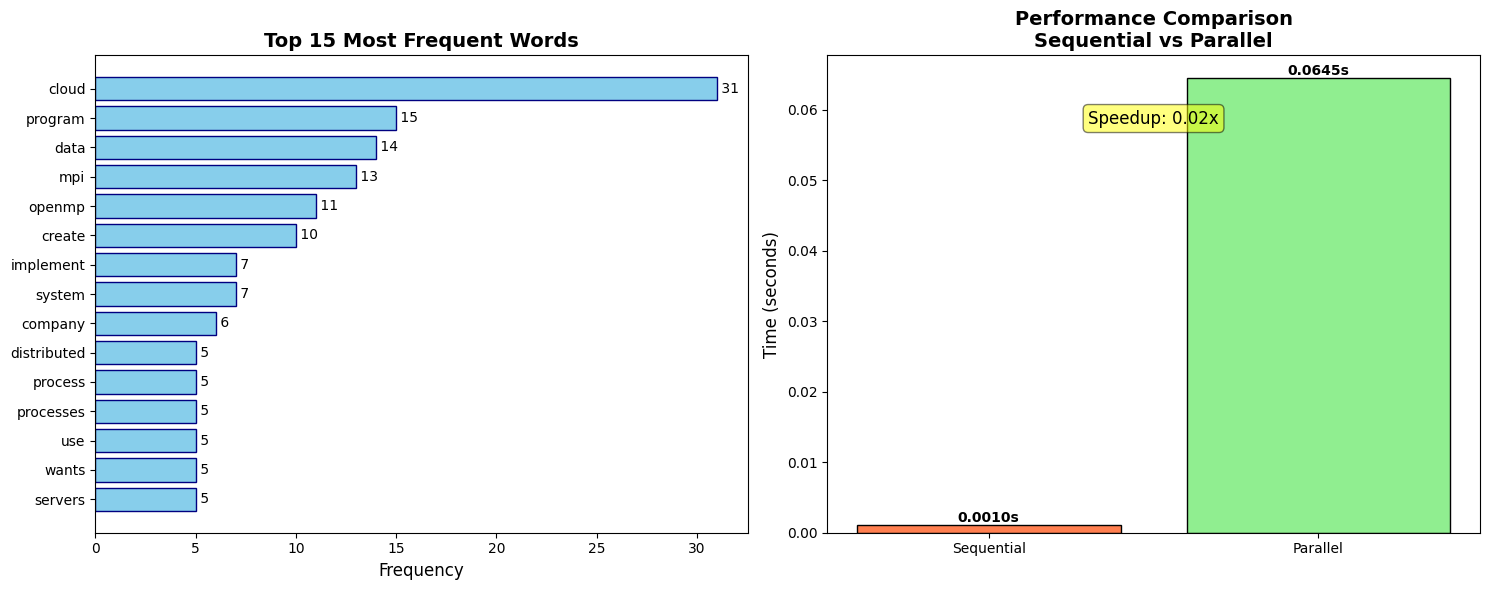


 Summary Statistics:
  • Total unique words: 254
  • Most common word: 'cloud' (31 times)
  • Parallel speedup: 0.02x faster

 Processing complete!


In [ ]:

if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 PARALLEL WORD COUNT SYSTEM")
    print("MapReduce Architecture with Parallel Processing")
    print("="*60)


    while True:
        choice = input("\nSelect input method:\n1. Enter text manually\n2. Upload PDF file\n\nChoice (1/2): ").strip()

        if choice == '1':
            text = main_text_mode()
            break
        elif choice == '2':
            text = main_pdf_mode()
            break
        else:
            print("Invalid choice! Please enter 1 or 2.")

    if not text or len(text.strip()) < 10:
        print("\n Error: Text is too short or empty!")
    else:
        print(f"\n Processing text of length: {len(text):,} characters")


        print("\n Running sequential processing...")
        seq_freq, seq_time = process_sequential(text)
        seq_total, seq_unique = compute_statistics(seq_freq)


        print(f" Running parallel processing with {NUM_WORKERS} workers...")
        par_freq, par_time = process_parallel(text, NUM_WORKERS)
        par_total, par_unique = compute_statistics(par_freq)


        if seq_total == par_total and seq_unique == par_unique:
            print(" Results verification: PASSED (sequential matches parallel)")
        else:
            print(" Results verification: WARNING (mismatch detected)")


        display_results(par_freq, par_total, par_unique, seq_time, par_time, top_n=20)


        print("\n Generating visualizations...")
        visualize_results(par_freq, seq_time, par_time, top_n=15)

        print("\n Processing complete!")